11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


C:\Users\Riddhi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9468 - loss: 0.1848 - val_accuracy: 0.9803 - val_loss: 0.0743
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9832 - loss: 0.0549 - val_accuracy: 0.9853 - val_loss: 0.0496
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9886 - loss: 0.0368 - val_accuracy: 0.9861 - val_loss: 0.0460
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9916 - loss: 0.0274 - val_accuracy: 0.9865 - val_loss: 0.0485
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.9875 - val_loss: 0.0456
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0371
Test Accuracy: 0.9876999855041504
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


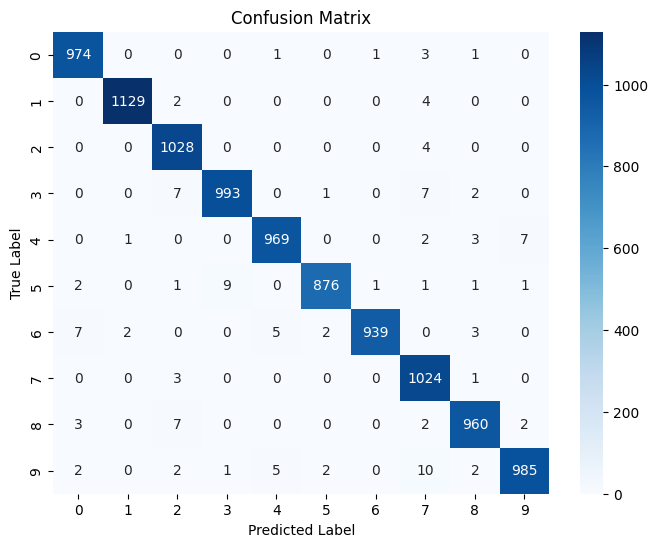

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix


(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


X_train = X_train / 255.0
X_test = X_test / 255.0


X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)


y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)


model = Sequential()

# Convolution layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))

# Pooling layer
model.add(MaxPooling2D((2,2)))

# Second convolution layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten layer
model.add(Flatten())

# Dense layers
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", test_accuracy)


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()